# Day 1 — Unsupervised Learning & K-Means

## Objectives

- Explain supervised vs. unsupervised learning.
- Apply K-Means clustering.
- Choose the number of clusters using the Elbow Method and Silhouette Score.
- Visualize and interpret the resulting clusters.

# Day 1 — Unsupervised Learning & K-Means

## Objectives

- Explain supervised vs. unsupervised learning.
- Run K-Means clustering and interpret the resulting clusters and centroids.
- Choose the number of clusters (`k`) using the Elbow Method and Silhouette Score.
- Visualize and interpret the resulting clusters.

## 1. Supervised vs. Unsupervised Learning

Supervised learning works with labeled data containing features (`X`) and a known target (`y`).
The model learns from the target and makes predictions on new data.

Unsupervised learning works with features (`X`) only and does not have a target variable.
Instead of predicting a known answer, the goal is to discover hidden structures in the data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Supervised vs. Unsupervised Learning

| Aspect | Supervised | Unsupervised |
|---|---|---|
| Data | X and y | X only |
| Goal | Predict a known target | Discover hidden structure |
| Examples | Classification, Regression | Clustering, Dimensionality Reduction |
| Evaluation | Compare predictions with true labels | Internal metrics and interpretation |

## 2. What Clustering Does

Clustering groups data points so that points within the same group are similar
to each other, while points in different groups are less similar.

The groups are not predefined. The algorithm discovers natural groupings
from the structure of the data.

## 3. K-Means Clustering

K-Means partitions the data into a chosen number of clusters (`k`).

The algorithm repeatedly:

1. Places `k` cluster centers (centroids).
2. Assigns each point to its nearest centroid.
3. Moves each centroid to the mean position of its assigned points.
4. Repeats the process until the centroids stabilize.

## 4. Load the Dataset

For this exercise, we will use the Titanic dataset.

Since K-Means is an unsupervised algorithm, we will not use
the target variable during clustering.

In [2]:
df = pd.read_csv(
    r"D:\Desktop\AI & ML BinX Tech\Python\Week 1\tested.csv"
)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
df.shape

(418, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


## 5. Select Numeric Features

K-Means works with numerical values because it relies on distance calculations.

We will use numeric features only and exclude the target variable
from the clustering process.

In [7]:
numeric_features = df.select_dtypes(include=np.number).columns

numeric_features

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')

In [8]:
features = numeric_features.drop("Survived")

X = df[features]

X.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
0,892,3,34.5,0,0,7.8292
1,893,3,47.0,1,0,7.0000
2,894,2,62.0,0,0,9.6875
3,895,3,27.0,0,0,8.6625
4,896,3,22.0,1,1,12.2875


In [9]:
X.isnull().sum()

PassengerId     0
Pclass          0
Age            86
SibSp           0
Parch           0
Fare            1
dtype: int64

## 6. Feature Scaling

K-Means is distance-based, so features with larger numerical ranges
can dominate the distance calculation.

To give each feature a comparable scale, we use StandardScaler.

In [13]:
features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

X = df[features].copy()

X.isnull().sum()

Pclass     0
Age       86
SibSp      0
Parch      0
Fare       1
dtype: int64

In [14]:
X = X.fillna(X.median())

X.isnull().sum()

Pclass    0
Age       0
SibSp     0
Parch     0
Fare      0
dtype: int64

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.87348191,  0.38623105, -0.49947002, -0.4002477 , -0.49741333],
       [ 0.87348191,  1.37137004,  0.61699237, -0.4002477 , -0.51227801],
       [-0.31581919,  2.55353683, -0.49947002, -0.4002477 , -0.46410047],
       [ 0.87348191, -0.20485235, -0.49947002, -0.4002477 , -0.48247516],
       [ 0.87348191, -0.59890794,  0.61699237,  0.61989583, -0.4174915 ]])

In [17]:
inertias = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    km.fit(X_scaled)
    inertias.append(km.inertia_)

print(inertias)

[2090.000000000001, 1492.7107082127077, 1186.100871786904, 975.3936912514441, 826.5412116306088, 702.2958918853285, 599.4231084065823, 545.4781262420358, 505.610357789775, 465.6952921736579]


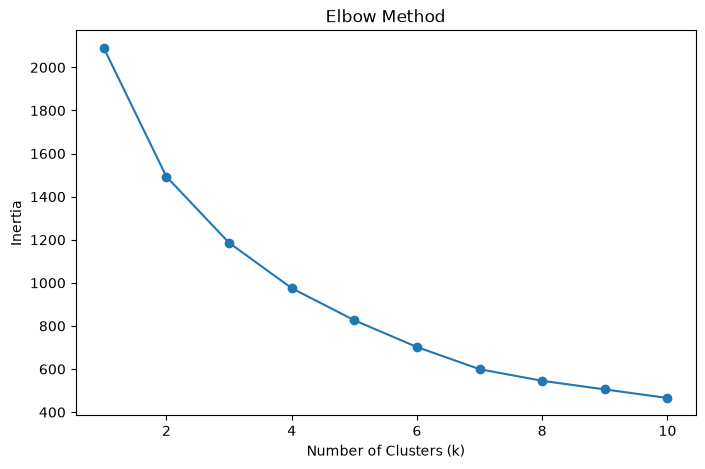

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), inertias, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

## 8. Choosing k: Silhouette Score

The Elbow Method gives us a visual estimate of the appropriate number
of clusters.

The Silhouette Score provides a quantitative check. It measures how well
each data point fits within its assigned cluster compared with the nearest
other cluster.

The score ranges from -1 to +1, and higher values indicate better-defined
clusters.

In [20]:
candidate_k = [2, 3, 4]

silhouette_scores = {}

for k in candidate_k:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = km.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score

silhouette_scores

{2: 0.4073072947080847, 3: 0.4378044416344435, 4: 0.4129758048849202}

In [21]:
for k, score in silhouette_scores.items():
    print(f"k={k}: Silhouette Score = {score:.3f}")

k=2: Silhouette Score = 0.407
k=3: Silhouette Score = 0.438
k=4: Silhouette Score = 0.413


## 9. Selecting the Final Number of Clusters

The silhouette scores were compared for k values of 2, 3, and 4.

The highest silhouette score was achieved with k = 3.

Therefore, we will use 3 clusters for the final K-Means model.

In [22]:
best_k = 3

final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

cluster_labels[:10]

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

## 10. Cluster Centers

The centroids represent the mean position of the observations
within each cluster in the scaled feature space.

In [23]:
centroids = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=features
)

centroids

,Pclass,Age,SibSp,Parch,Fare
0,0.538468,-0.348044,-0.177111,-0.163172,-0.394451
1,-1.376279,0.895876,0.021546,0.041814,0.921214
2,0.873482,-0.618611,3.408148,2.951652,0.105595


In [24]:
df_clustered = df.copy()

df_clustered["Cluster"] = cluster_labels

df_clustered.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cluster
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,1
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0


In [25]:
df_clustered["Cluster"].value_counts().sort_index()

Cluster
0    284
1    120
2     14
Name: count, dtype: int64

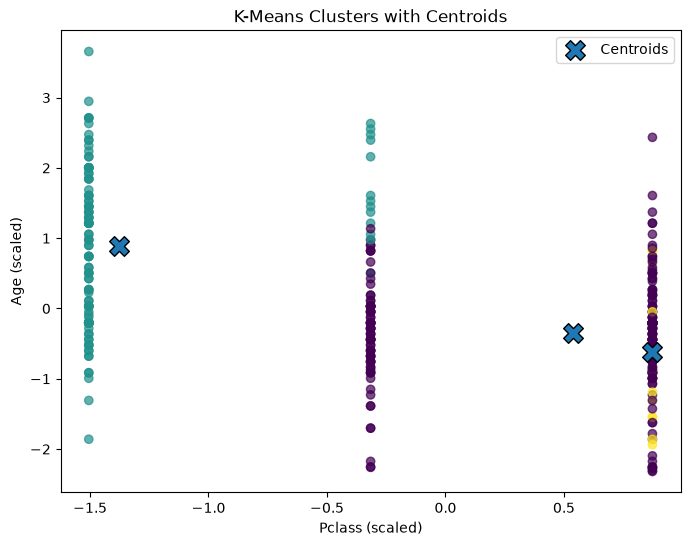

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=cluster_labels,
    alpha=0.7
)

plt.scatter(
    final_kmeans.cluster_centers_[:, 0],
    final_kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    edgecolor="black",
    label="Centroids"
)

plt.xlabel(f"{features[0]} (scaled)")
plt.ylabel(f"{features[1]} (scaled)")
plt.title("K-Means Clusters with Centroids")
plt.legend()

plt.show()

## 11. Cluster Interpretation

The clusters represent groups of Titanic passengers with similar
patterns across the selected numerical features.

The cluster characteristics will be interpreted based on the
feature distributions and cluster centroids.

In [27]:
cluster_summary = df_clustered.groupby("Cluster")[features].mean()

cluster_summary

,Pclass,Age,SibSp,Parch,Fare
Cluster,,,,,
0,2.718310,24.542857,0.288732,0.232394,13.569685
1,1.108333,42.099099,0.466667,0.433333,86.964827
2,3.000000,20.318182,3.500000,3.285714,41.466964


## 12. Cluster Interpretation

The K-Means model identified three distinct passenger groups.

- **Cluster 0:** Passengers with a higher average Pclass value (2.72),
  younger average age (24.54), low SibSp and Parch values, and relatively
  low average fare (13.57). This cluster mainly represents younger
  passengers with lower-fare tickets.

- **Cluster 1:** Passengers with the lowest average Pclass value (1.11),
  higher average age (42.10), and the highest average fare (86.96).
  This cluster represents older passengers who generally traveled in
  higher-class and higher-fare tickets.

- **Cluster 2:** Passengers with Pclass = 3 on average, a younger average
  age (20.32), and substantially higher SibSp and Parch values. This group
  represents younger passengers traveling with larger family groups.

Overall, K-Means discovered meaningful groups based on passenger class,
age, family-related variables, and fare without using the target variable.

## Key Takeaways

- K-Means was used to discover passenger groups without using a target variable.
- Features were scaled before clustering because K-Means is distance-based.
- The Elbow Method was used to evaluate the appropriate number of clusters.
- Silhouette Score was used as a quantitative measure to compare candidate values of k.
- Among the tested values, k = 3 achieved the highest Silhouette Score (0.438).
- The final model produced three interpretable passenger clusters.

## 13. Day 1 Summary

In this exercise, K-Means clustering was applied to the Titanic dataset
to discover passenger groups without using the target variable.

The numerical features were selected and missing values were handled
using median imputation. The features were then standardized using
StandardScaler because K-Means is based on distance calculations.

The Elbow Method was used to evaluate different values of k, while
the Silhouette Score was used to quantitatively compare candidate
cluster configurations.

Among the tested values, k = 3 achieved the highest Silhouette Score
of 0.438. The final K-Means model therefore used three clusters.

The resulting clusters showed different passenger characteristics
based mainly on passenger class, age, family-related variables,
and fare.